# Stage 0 — Lensing Simulation Prototype (Revised)

**Goal:** Take real COSMOS galaxy cutouts from the previous notebook and simulate gravitational lensing
to produce matched (LR 64×64, HR 128×128) image pairs at HSC-like instrument specifications.

---

### What is revised in this version
- Fix the COSMOS source pixel scale mismatch by reading the pixel scale from the metadata when available.
- Add survey-parameter sampling helpers for PSF, lens geometry, source offsets, and noise.
- Add automatic arc-SNR control that calibrates source amplitude to a sampled target SNR.
- Keep the old Gaussian-noise-without-exposure-time line as a comment, and add the requested exposure-scaled Gaussian term.
- Clean up the coordinate-system comment so it matches the implemented convention.

### Pipeline position
```
01_cosmos_cutout_extraction.ipynb
 -> cosmos_irsa_auto/npy/cosmos_XXXXXX.npy (real source galaxies)
 |
 v
THIS NOTEBOOK (02_lensing_simulation_prototype_revised.ipynb)
 -> SIE lens + sampled Moffat PSF + sampled HSC-like noise -> HR 128x128
 -> Downsample 2x -> LR 64x64
 -> Arc morphology validation
 |
 v
03_full_stage0_pipeline.py (scale up to 60,000 pairs)
```

## Cell 1 — Install dependencies

In [1]:
import subprocess, sys

packages = ['lenstronomy', 'numpy', 'matplotlib', 'scipy', 'tqdm', 'pandas', 'astropy']

for pkg in packages:
    result = subprocess.run(
        [sys.executable, '-m', 'pip', 'install', pkg, '-q'],
        capture_output=True, text=True
    )
    print(f'[{"OK" if result.returncode == 0 else "FAIL"}] {pkg}')

import lenstronomy
print(f'lenstronomy version: {lenstronomy.__version__}')

[OK] lenstronomy
[OK] numpy
[OK] matplotlib
[OK] scipy
[OK] tqdm
[OK] pandas
[OK] astropy
lenstronomy version: 1.14.0


## Cell 2 — Imports and configuration

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import json
import warnings
from pathlib import Path
from tqdm.notebook import tqdm

from lenstronomy.LensModel.lens_model import LensModel
from lenstronomy.LightModel.light_model import LightModel
from lenstronomy.ImSim.image_model import ImageModel
from lenstronomy.Data.imaging_data import ImageData
from lenstronomy.Data.psf import PSF
from lenstronomy.Util import kernel_util

warnings.filterwarnings('ignore')

# ── Instrument parameters ──────────────────────────────────────────────────────
PIX_LR = 0.168  # arcsec/px — HSC native scale
PIX_HR = PIX_LR / 2.0  # 2x super-resolution target = 0.084 arcsec/px

N_HR = 128
N_LR = 64
FOV = N_HR * PIX_HR

# Nominal/default values; the revised notebook also samples around these.
PSF_FWHM_ARCSEC = 0.7
PSF_MOFFAT_BETA = 3.0
PSF_KERNEL_SIZE = 21
SKY_RMS = 0.04
EXPOSURE_TIME = 1800.0
EINSTEIN_RADIUS = 1.0

# Full-pipeline sampling ranges motivated by your proposal / HSC-like prototype setup.
PSF_FWHM_RANGE = (0.6, 0.9)
SKY_RMS_RANGE = (0.03, 0.05)
EINSTEIN_RADIUS_RANGE = (0.8, 1.3)
LENS_E_RANGE = (-0.2, 0.2)
LENS_CENTER_RANGE = (-0.1, 0.1)
SRC_OFFSET_RANGE = (-0.3, 0.3)
TARGET_ARC_SNR_RANGE = (12.0, 40.0)
ROTATION_RANGE = (0.0, 2*np.pi)

# Source pixel scale will be overwritten from metadata in Cell 3 when available.
SRC_PIX_SCALE = 0.03

SUPERSAMPLING = 3
RNG_SEED = 42
RNG = np.random.default_rng(RNG_SEED)

SRC_DIR = Path('cosmos_irsa_auto/npy')
META_PATH = Path('cosmos_irsa_auto/metadata/cutout_metadata.json')
OUT_DIR = Path('lensing_sim_output_revised')
OUT_DIR.mkdir(exist_ok=True)
(OUT_DIR / 'hr').mkdir(exist_ok=True)
(OUT_DIR / 'lr').mkdir(exist_ok=True)
(OUT_DIR / 'preview').mkdir(exist_ok=True)

print(f'HR: {N_HR}x{N_HR} px @ {PIX_HR}"/px = {N_HR*PIX_HR:.2f}" FoV')
print(f'LR: {N_LR}x{N_LR} px @ {PIX_LR}"/px = {N_LR*PIX_LR:.2f}" FoV')
print(f'Default PSF FWHM: {PSF_FWHM_ARCSEC}" beta={PSF_MOFFAT_BETA}')
print(f'Default sky rms: {SKY_RMS}  exposure: {EXPOSURE_TIME}s')
print(f'Default Einstein radius: {EINSTEIN_RADIUS}"')
print(f'Initial source pixel scale: {SRC_PIX_SCALE}"/px')
print(f'Output directory: {OUT_DIR.resolve()}')

HR: 128x128 px @ 0.084"/px = 10.75" FoV
LR: 64x64 px @ 0.168"/px = 10.75" FoV
Default PSF FWHM: 0.7" beta=3.0
Default sky rms: 0.04  exposure: 1800.0s
Default Einstein radius: 1.0"
Initial source pixel scale: 0.03"/px
Output directory: C:\Users\upraj\Prajwal\GSOC\DeepLense\DeepLense_Unsupervised_Super_Resolution_Prajwal_Uday\stage_0\lensing_sim_output_revised


## Cell 3 — Load COSMOS cutouts and metadata

In [3]:
SRC_DIR = Path("cosmos_irsa_auto/npy")
META_PATH = Path("cosmos_irsa_auto/metadata/cutout_metadata.json")

npy_files = sorted(SRC_DIR.glob("cosmos_*.npy"))
if len(npy_files) == 0:
    npy_files = sorted(SRC_DIR.glob("*.npy"))

assert len(npy_files) > 0, f"No .npy files found in {SRC_DIR}. Run notebook 01 first."
source_galaxies = [np.load(f).astype(np.float32) for f in npy_files]

print(f"Loaded {len(source_galaxies)} source galaxy cutouts.")
print(f"First file: {npy_files[0].name}")
print(f"Shape: {source_galaxies[0].shape} dtype: {source_galaxies[0].dtype}")
print(f"Value range: [{source_galaxies[0].min():.4f}, {source_galaxies[0].max():.4f}]")

with open(META_PATH, "r", encoding="utf-8") as f:
    metadata = json.load(f)

meta_df = pd.DataFrame(metadata)
print(f"Metadata loaded: {len(meta_df)} entries")
print("Metadata columns:", list(meta_df.columns))

loaded_names = [f.name for f in npy_files]
if "filename" in meta_df.columns:
    meta_df["match_name"] = meta_df["filename"].astype(str)
elif "source_id" in meta_df.columns:
    meta_df["match_name"] = meta_df["source_id"].astype(str) + ".npy"
else:
    meta_df["match_name"] = None

matched_meta = meta_df[meta_df["match_name"].isin(loaded_names)].copy().reset_index(drop=True)
print(f"Matched metadata rows: {len(matched_meta)} / {len(npy_files)}")

preferred_cols = [
    "source_id", "filename", "ra", "dec",
    "mag_auto", "flux_radius", "elongation",
    "axis_ratio_est", "pixel_scale_arcsec", "cutout_size_arcsec"
]
show_cols = [c for c in preferred_cols if c in matched_meta.columns]
if len(show_cols) > 0:
    print("Matched metadata preview:")
    print(matched_meta[show_cols].head())

if "pixel_scale_arcsec" in matched_meta.columns and matched_meta["pixel_scale_arcsec"].notna().any():
    unique_scales = sorted(matched_meta["pixel_scale_arcsec"].dropna().unique().tolist())
    print("Unique source pixel scales from metadata:", unique_scales)
    if len(unique_scales) == 1:
        SRC_PIX_SCALE = float(unique_scales[0])
        print(f"Using metadata-derived source pixel scale: {SRC_PIX_SCALE:.5f} arcsec/px")
    else:
        SRC_PIX_SCALE = float(np.median(unique_scales))
        print(f"Multiple source scales found; using median value: {SRC_PIX_SCALE:.5f} arcsec/px")
else:
    print(f"No metadata pixel scale found; keeping default SRC_PIX_SCALE={SRC_PIX_SCALE:.5f}")

Loaded 50 source galaxy cutouts.
First file: cosmos_000001.npy
Shape: (168, 168) dtype: float32
Value range: [-0.6654, 5.0000]
Metadata loaded: 50 entries
Metadata columns: ['source_id', 'filename', 'ra', 'dec', 'shape', 'pixel_scale_arcsec', 'cutout_size_arcsec', 'sky_level', 'p99_flux', 'mag_auto', 'flux_radius', 'elongation', 'axis_ratio_est', 'stdnorm', 'peaknorm', 'edgeabsmean', 'finitefraction', 'main_flux_fraction', 'n_components', 'mask_fraction', 'saved_variant']
Matched metadata rows: 50 / 50
Matched metadata preview:
       source_id           filename          ra       dec   mag_auto  \
0  cosmos_000001  cosmos_000001.npy  149.959697  2.368358  23.280176   
1  cosmos_000003  cosmos_000003.npy  149.728648  2.360403  22.063015   
2  cosmos_000009  cosmos_000009.npy  150.455495  2.074121  24.810986   
3  cosmos_000017  cosmos_000017.npy  150.404548  2.116728  23.182703   
4  cosmos_000032  cosmos_000032.npy  150.332226  2.339665  21.820763   

   flux_radius  elongation  axis_

## Cell 4 — lenstronomy setup helpers

### Notes on the revised prototype
1. The coordinate comment now matches the implemented convention: x increases to the right and y increases upward.
2. The PSF and noise are now sampled through a helper rather than always fixed.
3. Arc-SNR control is added through a simple amplitude calibration loop.

In [4]:
def make_image_data(n_pix, pixel_scale, sky_rms=SKY_RMS, exp_time=EXPOSURE_TIME):
    """
    Create a lenstronomy ImageData object defining the output image grid.

    The coordinate system is centred: pixel (n_pix/2, n_pix/2) maps to (ra=0, dec=0).
    In this notebook convention, x increases to the right and y increases upward.
    The later plotting code uses the same convention.
    """
    transform = np.array([
        [pixel_scale, 0.0],
        [0.0, pixel_scale]
    ])

    ra_at_0 = -(n_pix / 2.0 - 0.5) * pixel_scale
    dec_at_0 = -(n_pix / 2.0 - 0.5) * pixel_scale

    return ImageData(
        image_data=np.zeros((n_pix, n_pix), dtype=np.float64),
        ra_at_xy_0=ra_at_0,
        dec_at_xy_0=dec_at_0,
        transform_pix2angle=transform,
        background_rms=sky_rms,
        exposure_time=exp_time,
    )


def make_moffat_psf(fwhm_arcsec, pixel_scale, beta=PSF_MOFFAT_BETA, kernel_size=PSF_KERNEL_SIZE):
    """
    Build a normalised Moffat PSF kernel for lenstronomy.
    """
    if kernel_size % 2 == 0:
        kernel_size += 1

    kernel = kernel_util.kernel_moffat(
        num_pix=kernel_size,
        delta_pix=pixel_scale,
        fwhm=fwhm_arcsec,
        moffat_beta=beta,
    )
    kernel = kernel_util.kernel_norm(kernel)
    return PSF(psf_type='PIXEL', kernel_point_source=kernel, pixel_size=pixel_scale)


def sample_survey_params(rng):
    """
    Prototype survey-calibrated sampling.

    This is the right Stage-0 implementation style for now: sample from ranges chosen
    from survey-like specifications and early data inspection. Later you can replace
    these with empirical distributions measured from real survey metadata.
    """
    return {
        'theta_E': rng.uniform(*EINSTEIN_RADIUS_RANGE),
        'lens_e1': rng.uniform(*LENS_E_RANGE),
        'lens_e2': rng.uniform(*LENS_E_RANGE),
        'lens_cx': rng.uniform(*LENS_CENTER_RANGE),
        'lens_cy': rng.uniform(*LENS_CENTER_RANGE),
        'src_offset_x': rng.uniform(*SRC_OFFSET_RANGE),
        'src_offset_y': rng.uniform(*SRC_OFFSET_RANGE),
        'src_rotation': rng.uniform(*ROTATION_RANGE),
        'psf_fwhm': rng.uniform(*PSF_FWHM_RANGE),
        'sky_rms': rng.uniform(*SKY_RMS_RANGE),
        'exp_time': EXPOSURE_TIME,
        'target_arc_snr': rng.uniform(*TARGET_ARC_SNR_RANGE),
    }


def estimate_arc_snr_peak(clean_image, sky_rms, eps=1e-8):
    """
    Simple prototype SNR proxy used for amplitude calibration.
    """
    peak = float(np.nanmax(clean_image))
    return peak / max(float(sky_rms), eps)


def add_hsc_noise(img_clean, sky_rms=SKY_RMS, exp_time=EXPOSURE_TIME, rng=None):
    """
    Add HSC-like noise to a noiseless lensed image.

    - Poisson term is generated in count space using exp_time.
    - Gaussian term is now exposure-scaled, as requested.
    - The old fixed-sigma line is kept commented out below.
    """
    if rng is None:
        rng = np.random.default_rng()

    img_counts = np.clip(img_clean, 0, None) * exp_time
    poisson_counts = rng.poisson(img_counts).astype(np.float64)
    img_noisy = poisson_counts / exp_time

    # Old usage without exposure-time scaling:
    # sky_noise = rng.normal(loc=0.0, scale=sky_rms, size=img_clean.shape)

    gaussian_sigma = sky_rms / np.sqrt(max(exp_time, 1e-12))
    sky_noise = rng.normal(loc=0.0, scale=gaussian_sigma, size=img_clean.shape)
    img_noisy += sky_noise

    return img_noisy.astype(np.float32)


def downsample_2x(img):
    h, w = img.shape
    assert h % 2 == 0 and w % 2 == 0, 'HR image must have even dimensions'
    return img.reshape(h // 2, 2, w // 2, 2).mean(axis=(1, 3)).astype(np.float32)


print('Helper functions defined:')
print(' make_image_data()      : lenstronomy ImageData grid')
print(' make_moffat_psf()      : Moffat PSF kernel for lenstronomy')
print(' sample_survey_params() : sampled Stage-0 survey-like parameters')
print(' estimate_arc_snr_peak(): prototype arc-SNR proxy')
print(' add_hsc_noise()        : Poisson + Gaussian noise with exp_time scaling')
print(' downsample_2x()        : 2x2 block average HR->LR')

Helper functions defined:
 make_image_data()      : lenstronomy ImageData grid
 make_moffat_psf()      : Moffat PSF kernel for lenstronomy
 sample_survey_params() : sampled Stage-0 survey-like parameters
 estimate_arc_snr_peak(): prototype arc-SNR proxy
 add_hsc_noise()        : Poisson + Gaussian noise with exp_time scaling
 downsample_2x()        : 2x2 block average HR->LR


## Cell 5 — Core simulation function with arc-SNR calibration

In [5]:
def render_lensed_hr_clean(
    source_img: np.ndarray,
    theta_E: float,
    lens_e1: float,
    lens_e2: float,
    lens_cx: float,
    lens_cy: float,
    src_offset_x: float,
    src_offset_y: float,
    src_rotation: float,
    src_amp: float,
    psf_fwhm: float,
    sky_rms: float,
    exp_time: float,
):
    data = make_image_data(n_pix=N_HR, pixel_scale=PIX_HR, sky_rms=sky_rms, exp_time=exp_time)
    psf = make_moffat_psf(fwhm_arcsec=psf_fwhm, pixel_scale=PIX_HR)

    lens_model = LensModel(lens_model_list=['SIE'])
    kwargs_lens = [{
        'theta_E': theta_E,
        'e1': lens_e1,
        'e2': lens_e2,
        'center_x': lens_cx,
        'center_y': lens_cy,
    }]

    source_model = LightModel(light_model_list=['INTERPOL'])
    kwargs_source = [{
        'image': source_img.astype(np.float64),
        'amp': src_amp,
        'center_x': src_offset_x,
        'center_y': src_offset_y,
        'phi_G': src_rotation,
        'scale': SRC_PIX_SCALE,
    }]

    image_model = ImageModel(
        data_class=data,
        psf_class=psf,
        lens_model_class=lens_model,
        source_model_class=source_model,
        kwargs_numerics={
            'supersampling_factor': SUPERSAMPLING,
            'supersampling_convolution': False,
        }
    )

    hr_clean = image_model.image(
        kwargs_lens=kwargs_lens,
        kwargs_source=kwargs_source,
    ).astype(np.float32)

    return hr_clean, kwargs_lens, kwargs_source


def calibrate_source_amplitude_for_target_snr(
    source_img,
    target_arc_snr,
    theta_E,
    lens_e1,
    lens_e2,
    lens_cx,
    lens_cy,
    src_offset_x,
    src_offset_y,
    src_rotation,
    psf_fwhm,
    sky_rms,
    exp_time,
    initial_amp=10.0,
    max_iter=8,
    tol_frac=0.10,
):
    """
    Calibrate src_amp so the clean HR lensed arc approximately matches a target arc-SNR proxy.
    """
    src_amp = float(initial_amp)
    achieved_snr = np.nan
    hr_clean = None

    for _ in range(max_iter):
        hr_clean, kwargs_lens, kwargs_source = render_lensed_hr_clean(
            source_img=source_img,
            theta_E=theta_E,
            lens_e1=lens_e1,
            lens_e2=lens_e2,
            lens_cx=lens_cx,
            lens_cy=lens_cy,
            src_offset_x=src_offset_x,
            src_offset_y=src_offset_y,
            src_rotation=src_rotation,
            src_amp=src_amp,
            psf_fwhm=psf_fwhm,
            sky_rms=sky_rms,
            exp_time=exp_time,
        )
        achieved_snr = estimate_arc_snr_peak(hr_clean, sky_rms)
        if not np.isfinite(achieved_snr) or achieved_snr <= 0:
            src_amp *= 2.0
            continue
        rel_err = abs(achieved_snr - target_arc_snr) / max(target_arc_snr, 1e-8)
        if rel_err <= tol_frac:
            break
        src_amp *= target_arc_snr / max(achieved_snr, 1e-8)

    return {
        'src_amp': float(src_amp),
        'achieved_arc_snr_clean': float(achieved_snr),
        'target_arc_snr': float(target_arc_snr),
        'hr_clean': hr_clean,
        'kwargs_lens': kwargs_lens,
        'kwargs_source': kwargs_source,
    }


def simulate_lensed_pair(
    source_img: np.ndarray,
    theta_E: float = EINSTEIN_RADIUS,
    lens_e1: float = 0.05,
    lens_e2: float = 0.02,
    lens_cx: float = 0.0,
    lens_cy: float = 0.0,
    src_offset_x: float = 0.1,
    src_offset_y: float = 0.05,
    src_rotation: float = 0.0,
    src_amp: float = None,
    target_arc_snr: float = 20.0,
    psf_fwhm: float = PSF_FWHM_ARCSEC,
    sky_rms: float = SKY_RMS,
    exp_time: float = EXPOSURE_TIME,
    rng: np.random.Generator = None,
) -> dict:
    """
    Simulate one lensed HR/LR pair, with optional arc-SNR-driven source amplitude calibration.
    """
    if rng is None:
        rng = np.random.default_rng()

    if src_amp is None:
        cal = calibrate_source_amplitude_for_target_snr(
            source_img=source_img,
            target_arc_snr=target_arc_snr,
            theta_E=theta_E,
            lens_e1=lens_e1,
            lens_e2=lens_e2,
            lens_cx=lens_cx,
            lens_cy=lens_cy,
            src_offset_x=src_offset_x,
            src_offset_y=src_offset_y,
            src_rotation=src_rotation,
            psf_fwhm=psf_fwhm,
            sky_rms=sky_rms,
            exp_time=exp_time,
            initial_amp=10.0,
        )
        src_amp = cal['src_amp']
        hr_clean = cal['hr_clean']
        achieved_arc_snr_clean = cal['achieved_arc_snr_clean']
    else:
        hr_clean, _, _ = render_lensed_hr_clean(
            source_img=source_img,
            theta_E=theta_E,
            lens_e1=lens_e1,
            lens_e2=lens_e2,
            lens_cx=lens_cx,
            lens_cy=lens_cy,
            src_offset_x=src_offset_x,
            src_offset_y=src_offset_y,
            src_rotation=src_rotation,
            src_amp=src_amp,
            psf_fwhm=psf_fwhm,
            sky_rms=sky_rms,
            exp_time=exp_time,
        )
        achieved_arc_snr_clean = estimate_arc_snr_peak(hr_clean, sky_rms)

    hr_noisy = add_hsc_noise(hr_clean, sky_rms=sky_rms, exp_time=exp_time, rng=rng)
    lr_noisy = downsample_2x(hr_noisy)

    return {
        'hr': hr_noisy,
        'lr': lr_noisy,
        'hr_clean': hr_clean,
        'params': {
            'theta_E': theta_E,
            'lens_e1': lens_e1,
            'lens_e2': lens_e2,
            'lens_cx': lens_cx,
            'lens_cy': lens_cy,
            'src_offset_x': src_offset_x,
            'src_offset_y': src_offset_y,
            'src_rotation': src_rotation,
            'src_amp': float(src_amp),
            'target_arc_snr': float(target_arc_snr),
            'achieved_arc_snr_clean': float(achieved_arc_snr_clean),
            'psf_fwhm': psf_fwhm,
            'sky_rms': sky_rms,
            'exp_time': exp_time,
            'src_pix_scale': SRC_PIX_SCALE,
        }
    }


print('simulate_lensed_pair() defined.')

simulate_lensed_pair() defined.


## Cell 6 — Test: sample parameters and simulate a single lensed pair

In [6]:
print('Sampling survey-like parameters and simulating one test lensed pair ...')

test_src = source_galaxies[0]
test_meta = matched_meta.iloc[0].copy()

test_params = sample_survey_params(np.random.default_rng(RNG_SEED))
print('Sampled parameters:')
for k, v in test_params.items():
    if isinstance(v, float):
        print(f'  {k}: {v:.4f}')
    else:
        print(f'  {k}: {v}')

result = simulate_lensed_pair(
    source_img=test_src,
    theta_E=test_params['theta_E'],
    lens_e1=test_params['lens_e1'],
    lens_e2=test_params['lens_e2'],
    lens_cx=test_params['lens_cx'],
    lens_cy=test_params['lens_cy'],
    src_offset_x=test_params['src_offset_x'],
    src_offset_y=test_params['src_offset_y'],
    src_rotation=test_params['src_rotation'],
    src_amp=None,
    target_arc_snr=test_params['target_arc_snr'],
    psf_fwhm=test_params['psf_fwhm'],
    sky_rms=test_params['sky_rms'],
    exp_time=test_params['exp_time'],
    rng=np.random.default_rng(RNG_SEED),
)

hr_clean = result['hr_clean']
hr_noisy = result['hr']
lr_noisy = result['lr']

print(f'HR clean shape: {hr_clean.shape} max: {hr_clean.max():.4f}')
print(f'HR noisy shape: {hr_noisy.shape} max: {hr_noisy.max():.4f}')
print(f'LR noisy shape: {lr_noisy.shape} max: {lr_noisy.max():.4f}')
print(f"Target arc SNR:   {result['params']['target_arc_snr']:.2f}")
print(f"Achieved arc SNR: {result['params']['achieved_arc_snr_clean']:.2f}")
print(f"Calibrated src_amp: {result['params']['src_amp']:.4f}")

Sampling survey-like parameters and simulating one test lensed pair ...
Sampled parameters:
  theta_E: 1.1870
  lens_e1: -0.0244
  lens_e2: 0.1434
  lens_cx: 0.0395
  lens_cy: -0.0812
  src_offset_x: 0.2854
  src_offset_y: 0.1567
  src_rotation: 4.9390
  psf_fwhm: 0.6384
  sky_rms: 0.0390
  exp_time: 1800.0000
  target_arc_snr: 22.3823
HR clean shape: (128, 128) max: 0.8731
HR noisy shape: (128, 128) max: 0.9045
LR noisy shape: (64, 64) max: 0.8677
Target arc SNR:   22.38
Achieved arc SNR: 22.38
Calibrated src_amp: 51.6165


## Cell 7 — Visualise the first simulated pair in detail

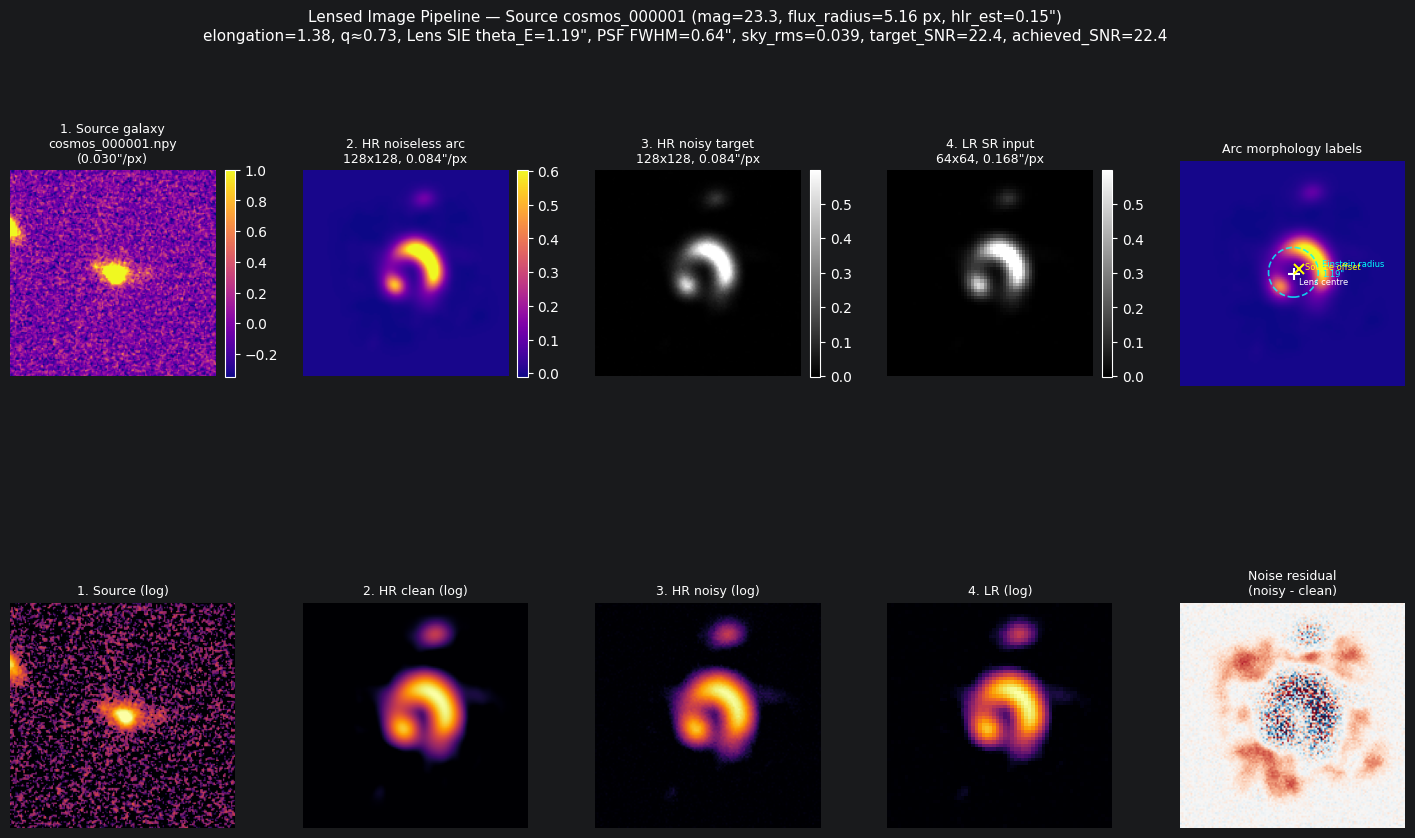

Saved: test_pair_detail.png


In [7]:
fig = plt.figure(figsize=(18, 10))

source_id = test_meta.get('source_id', 'unknown')
filename = test_meta.get('filename', 'unknown')
mag_auto = test_meta.get('mag_auto', np.nan)
flux_radius = test_meta.get('flux_radius', np.nan)
pixel_scale_arcsec = test_meta.get('pixel_scale_arcsec', SRC_PIX_SCALE)
elongation = test_meta.get('elongation', np.nan)
axis_ratio_est = test_meta.get('axis_ratio_est', np.nan)

hlr_arcsec_est = (
    float(flux_radius) * float(pixel_scale_arcsec)
    if pd.notna(flux_radius) and pd.notna(pixel_scale_arcsec)
    else np.nan
)

title_line1 = (
    f'Lensed Image Pipeline — Source {source_id} '
    f'(mag={mag_auto:.1f}, '
    f'flux_radius={flux_radius:.2f} px, '
    f'hlr_est={hlr_arcsec_est:.2f}")'
    if pd.notna(mag_auto) and pd.notna(flux_radius) and pd.notna(hlr_arcsec_est)
    else f'Lensed Image Pipeline — Source {source_id}'
)

title_line2 = (
    f'elongation={elongation:.2f}, q≈{axis_ratio_est:.2f}, '
    f'Lens SIE theta_E={result["params"]["theta_E"]:.2f}", '
    f'PSF FWHM={result["params"]["psf_fwhm"]:.2f}", '
    f'sky_rms={result["params"]["sky_rms"]:.3f}, '
    f'target_SNR={result["params"]["target_arc_snr"]:.1f}, '
    f'achieved_SNR={result["params"]["achieved_arc_snr_clean"]:.1f}'
    if pd.notna(elongation) and pd.notna(axis_ratio_est)
    else f'Lens SIE theta_E={result["params"]["theta_E"]:.2f}", '
    f'PSF FWHM={result["params"]["psf_fwhm"]:.2f}", '
    f'sky_rms={result["params"]["sky_rms"]:.3f}'
)

fig.suptitle(f'{title_line1}\n{title_line2}', fontsize=11)

gs = gridspec.GridSpec(2, 5, figure=fig, hspace=0.35, wspace=0.3)

panels_top = [
    (test_src, f'1. Source galaxy\n{filename}\n({pixel_scale_arcsec:.3f}"/px)', 'plasma'),
    (hr_clean, f'2. HR noiseless arc\n{N_HR}x{N_HR}, {PIX_HR:.3f}"/px', 'plasma'),
    (hr_noisy, f'3. HR noisy target\n{N_HR}x{N_HR}, {PIX_HR:.3f}"/px', 'gray'),
    (lr_noisy, f'4. LR SR input\n{N_LR}x{N_LR}, {PIX_LR:.3f}"/px', 'gray'),
]

for col, (img, title, cmap) in enumerate(panels_top):
    ax = fig.add_subplot(gs[0, col])
    p1, p99 = np.percentile(img, [1, 99])
    im = ax.imshow(img, cmap=cmap, origin='lower', vmin=p1, vmax=p99)
    ax.set_title(title, fontsize=9)
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

ax_ann = fig.add_subplot(gs[0, 4])
p1, p99 = np.percentile(hr_clean, [0.5, 99.5])
ax_ann.imshow(hr_clean, cmap='plasma', origin='lower', vmin=p1, vmax=p99)
ax_ann.set_title('Arc morphology labels', fontsize=9)
ax_ann.axis('off')

cx, cy = N_HR // 2, N_HR // 2
theta_E_px = result['params']['theta_E'] / PIX_HR
circle = plt.Circle((cx, cy), theta_E_px, fill=False, color='cyan', linewidth=1.2, linestyle='--', alpha=0.8)
ax_ann.add_patch(circle)
ax_ann.text(cx + theta_E_px + 2, cy + 2, f'Einstein radius\n{result["params"]["theta_E"]:.2f}"', color='cyan', fontsize=6, va='center')

lensx_px = cx + result['params']['lens_cx'] / PIX_HR
lensy_px = cy + result['params']['lens_cy'] / PIX_HR
ax_ann.plot(lensx_px, lensy_px, '+', color='white', markersize=8, markeredgewidth=1.5)
ax_ann.text(lensx_px + 3, lensy_px - 6, 'Lens centre', color='white', fontsize=6)

srcx_px = cx + result['params']['src_offset_x'] / PIX_HR
srcy_px = cy + result['params']['src_offset_y'] / PIX_HR
ax_ann.plot(srcx_px, srcy_px, 'x', color='yellow', markersize=7, markeredgewidth=1.5)
ax_ann.text(srcx_px + 3, srcy_px, 'Source offset', color='yellow', fontsize=6)

panels_bot = [
    (test_src, '1. Source (log)'),
    (hr_clean, '2. HR clean (log)'),
    (hr_noisy, '3. HR noisy (log)'),
    (lr_noisy, '4. LR (log)'),
]

for col, (img, title) in enumerate(panels_bot):
    ax = fig.add_subplot(gs[1, col])
    img_log = np.log1p(np.clip(img, 0, None) * 50)
    ax.imshow(img_log, cmap='inferno', origin='lower')
    ax.set_title(title, fontsize=9)
    ax.axis('off')

ax_noise = fig.add_subplot(gs[1, 4])
noise_residual = hr_noisy - hr_clean
vext = np.percentile(np.abs(noise_residual), 99)
ax_noise.imshow(noise_residual, cmap='RdBu_r', origin='lower', vmin=-vext, vmax=vext)
ax_noise.set_title('Noise residual\n(noisy - clean)', fontsize=9)
ax_noise.axis('off')

plt.savefig(OUT_DIR / 'test_pair_detail.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: test_pair_detail.png')

## Cell 8 — Mini batch demo with sampled survey parameters

In [8]:
mini_records = []
mini_n = min(6, len(source_galaxies))
mini_rng = np.random.default_rng(RNG_SEED + 1)

for i in range(mini_n):
    params = sample_survey_params(mini_rng)
    res = simulate_lensed_pair(
        source_img=source_galaxies[i],
        theta_E=params['theta_E'],
        lens_e1=params['lens_e1'],
        lens_e2=params['lens_e2'],
        lens_cx=params['lens_cx'],
        lens_cy=params['lens_cy'],
        src_offset_x=params['src_offset_x'],
        src_offset_y=params['src_offset_y'],
        src_rotation=params['src_rotation'],
        src_amp=None,
        target_arc_snr=params['target_arc_snr'],
        psf_fwhm=params['psf_fwhm'],
        sky_rms=params['sky_rms'],
        exp_time=params['exp_time'],
        rng=np.random.default_rng(RNG_SEED + 100 + i),
    )
    mini_records.append({
        'idx': i,
        'target_arc_snr': res['params']['target_arc_snr'],
        'achieved_arc_snr_clean': res['params']['achieved_arc_snr_clean'],
        'src_amp': res['params']['src_amp'],
        'psf_fwhm': res['params']['psf_fwhm'],
        'sky_rms': res['params']['sky_rms'],
        'theta_E': res['params']['theta_E'],
    })

mini_df = pd.DataFrame(mini_records)
display(mini_df.round(4))

,idx,target_arc_snr,achieved_arc_snr_clean,src_amp,psf_fwhm,sky_rms,theta_E
0,0,38.7488,38.7488,106.8299,0.7260,0.0390,1.1261
1,1,38.4635,38.4635,105.8232,0.7605,0.0397,1.2460
2,2,13.4174,13.4174,53.0923,0.6900,0.0410,1.0966
3,3,14.0736,14.0736,37.6199,0.6280,0.0418,1.0255
4,4,12.1109,12.1109,47.5135,0.7836,0.0330,1.0903
5,5,28.9821,28.9821,101.4777,0.6038,0.0379,1.2215


In [ ]:
mini_records = []
mini_n = min(6, len(source_galaxies))
mini_rng = np.random.default_rng(RNG_SEED + 1)

for i in range(mini_n):
    params = sample_survey_params(mini_rng)

    res = simulate_lensed_pair(
        source_img=source_galaxies[i],
        theta_E=params['theta_E'],
        lens_e1=params['lens_e1'],
        lens_e2=params['lens_e2'],
        lens_cx=params['lens_cx'],
        lens_cy=params['lens_cy'],
        src_offset_x=params['src_offset_x'],
        src_offset_y=params['src_offset_y'],
        src_rotation=params['src_rotation'],
        src_amp=None,
        target_arc_snr=params['target_arc_snr'],
        psf_fwhm=params['psf_fwhm'],
        sky_rms=params['sky_rms'],
        exp_time=params['exp_time'],
        rng=np.random.default_rng(RNG_SEED + 100 + i),
    )

    sample_id = f"sample_{i:05d}"

    np.save(OUT_DIR / "hr" / f"{sample_id}.npy", res["hr"].astype(np.float32))
    np.save(OUT_DIR / "lr" / f"{sample_id}.npy", res["lr"].astype(np.float32))

    fig, axes = plt.subplots(1, 2, figsize=(6, 3))

    axes[0].imshow(res["hr"], cmap="gray", origin="lower")
    axes[0].set_title("HR")
    axes[0].axis("off")

    axes[1].imshow(res["lr"], cmap="gray", origin="lower")
    axes[1].set_title("LR")
    axes[1].axis("off")

    plt.tight_layout()
    plt.savefig(OUT_DIR / "preview" / f"{sample_id}.png", dpi=120, bbox_inches="tight")
    plt.close(fig)

    mini_records.append({
        "idx": i,
        "sample_id": sample_id,
        "hr_path": str(OUT_DIR / "hr" / f"{sample_id}.npy"),
        "lr_path": str(OUT_DIR / "lr" / f"{sample_id}.npy"),
        "preview_path": str(OUT_DIR / "preview" / f"{sample_id}.png"),
        "target_arc_snr": res["params"]["target_arc_snr"],
        "achieved_arc_snr_clean": res["params"]["achieved_arc_snr_clean"],
        "src_amp": res["params"]["src_amp"],
        "psf_fwhm": res["params"]["psf_fwhm"],
        "sky_rms": res["params"]["sky_rms"],
        "theta_E": res["params"]["theta_E"],
    })

mini_df = pd.DataFrame(mini_records)
mini_df.to_csv(OUT_DIR / "mini_batch_metadata.csv", index=False)
display(mini_df.round(4))

print(f"Saved {mini_n} HR files to: {OUT_DIR / 'hr'}")
print(f"Saved {mini_n} LR files to: {OUT_DIR / 'lr'}")
print(f"Saved {mini_n} previews to: {OUT_DIR / 'preview'}")